# Part 3: Evaluation & Pipeline Integration
**Course:** BCS407 – Artificial Intelligence  
**Project:** AI-Based Vehicle Detection System  
**Classes:** bus · car · motorcycle · truck  

---
### What this notebook does
1. Loads the trained `best.pt` model from Part 2
2. Evaluates on the **test set** → precision, recall, mAP@0.5, mAP@0.5:0.95
3. Generates a **confusion matrix** with per-class breakdown
4. Plots **precision-recall curves** and a **performance summary bar chart**
5. Runs the **full end-to-end pipeline** (image → model → annotated output)
6. Provides a **live demo cell** for unseen images during presentation

## Step 1: Github & Install Dependencies

In [1]:
# Clone the repo from GitHub
!git clone -b feature/asma https://github.com/helloasma/vehicle-detection-project.git
%cd vehicle-detection-project

!pip install ultralytics -q
!pip install seaborn -q

import ultralytics
ultralytics.checks()
print('✅ Dependencies ready')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)
✅ Dependencies ready


## Step 2: Set Paths

In [2]:
import os, yaml

PROJECT_ROOT = '/content/vehicle-detection-project'

WEIGHTS_PATH = os.path.join(PROJECT_ROOT, 'scripts', 'part2_training', 'best.pt')
DATA_YAML    = os.path.join(PROJECT_ROOT, 'data.yaml')
OUTPUT_DIR   = os.path.join(PROJECT_ROOT, 'scripts', 'part3_evaluation')
os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(DATA_YAML, 'r') as f:
    config = yaml.safe_load(f)

config['path'] = PROJECT_ROOT
COLAB_YAML = '/content/data.yaml'
with open(COLAB_YAML, 'w') as f:
    yaml.dump(config, f)

print('Paths configured:')
print(f'  Weights : {WEIGHTS_PATH}')
print(f'  YAML    : {COLAB_YAML}')
print(f'  Outputs : {OUTPUT_DIR}')
print(f'  Weights exist: {os.path.exists(WEIGHTS_PATH)}')

Paths configured:
  Weights : /content/vehicle-detection-project/scripts/part2_training/best.pt
  YAML    : /content/data.yaml
  Outputs : /content/vehicle-detection-project/scripts/part3_evaluation
  Weights exist: True


## Step 3: Load Trained Model

In [3]:
from ultralytics import YOLO

model = YOLO(WEIGHTS_PATH)
CLASS_NAMES = ['bus', 'car', 'motorcycle', 'truck']
print(f'✅ Model loaded from: {WEIGHTS_PATH}')
print(f'   Classes: {CLASS_NAMES}')

✅ Model loaded from: /content/vehicle-detection-project/scripts/part2_training/best.pt
   Classes: ['bus', 'car', 'motorcycle', 'truck']


## Step 4: Evaluate on Test Set → Metrics
This runs the model on the 80 test images and reports **precision, recall, mAP@0.5, mAP@0.5:0.95** for each class and overall.

In [4]:
import pandas as pd
import numpy as np

print('Running evaluation on TEST set...')
test_results = model.val(
    data=COLAB_YAML,
    split='test',
    save_json=False,
    verbose=True
)

# ── Overall metrics ────────────────────────────────────────────────────────
overall_precision = test_results.box.mp
overall_recall    = test_results.box.mr
overall_map50     = test_results.box.map50
overall_map5095   = test_results.box.map

print('\n' + '='*50)
print('  OVERALL TEST SET RESULTS')
print('='*50)
print(f'  Precision    : {overall_precision:.4f}  ({overall_precision*100:.1f}%)')
print(f'  Recall       : {overall_recall:.4f}  ({overall_recall*100:.1f}%)')
print(f'  mAP@0.5      : {overall_map50:.4f}  ({overall_map50*100:.1f}%)')
print(f'  mAP@0.5:0.95 : {overall_map5095:.4f}  ({overall_map5095*100:.1f}%)')
print('='*50)

# ── Per-class metrics ──────────────────────────────────────────────────────
per_class_data = []
if hasattr(test_results.box, 'ap_class_index'):
    for i, cls_idx in enumerate(test_results.box.ap_class_index):
        cls_name = CLASS_NAMES[cls_idx]
        p  = float(test_results.box.p[i])  if test_results.box.p  is not None else 0
        r  = float(test_results.box.r[i])  if test_results.box.r  is not None else 0
        ap = float(test_results.box.ap50[i]) if test_results.box.ap50 is not None else 0
        per_class_data.append({'Class': cls_name, 'Precision': p, 'Recall': r, 'AP@0.5': ap})

df_metrics = pd.DataFrame(per_class_data)
if not df_metrics.empty:
    print('\nPer-Class Metrics:')
    print(df_metrics.to_string(index=False, float_format='{:.4f}'.format))
    df_metrics.to_csv(os.path.join(OUTPUT_DIR, 'per_class_metrics.csv'), index=False)
    print(f'\n✅ Saved: per_class_metrics.csv')
else:
    print('\n(Per-class breakdown not available from this ultralytics version.)')

Running evaluation on TEST set...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1317.4±617.9 MB/s, size: 47.3 KB)
val: Scanning /content/vehicle-detection-project/test/labels... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 1.9Kit/s 0.0s
val: New cache created: /content/vehicle-detection-project/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.4it/s 2.1s
                   all         80         96      0.963      0.898      0.932      0.792
                   bus         23         28      0.992      0.893      0.895      0.811
                   car         21         28      0.878      0.714      0.842      0.746
            motorcycle         15         15      0.984          1      0.995      0.728
                 truck

## Step 5: Metrics Bar Chart (Precision · Recall · mAP@0.5 per class)

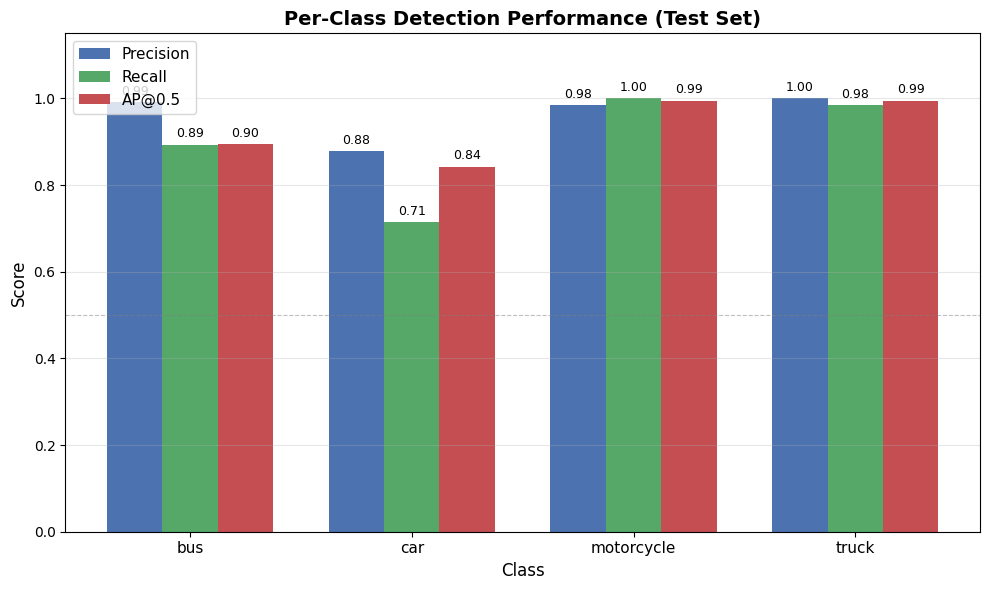

✅ Saved: metrics_bar_chart.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if df_metrics.empty:
    # Fallback: plot overall metrics as a single group
    classes = ['Overall']
    prec_vals = [overall_precision]
    rec_vals  = [overall_recall]
    map_vals  = [overall_map50]
else:
    classes   = df_metrics['Class'].tolist()
    prec_vals = df_metrics['Precision'].tolist()
    rec_vals  = df_metrics['Recall'].tolist()
    map_vals  = df_metrics['AP@0.5'].tolist()

x = np.arange(len(classes))
width = 0.25
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, prec_vals, width, label='Precision', color=colors[0])
bars2 = ax.bar(x,         rec_vals,  width, label='Recall',    color=colors[1])
bars3 = ax.bar(x + width, map_vals,  width, label='AP@0.5',    color=colors[2])

# Value labels on bars
for bar_group in [bars1, bars2, bars3]:
    for bar in bar_group:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Detection Performance (Test Set)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, 'metrics_bar_chart.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: metrics_bar_chart.png')

## Step 6: Confusion Matrix

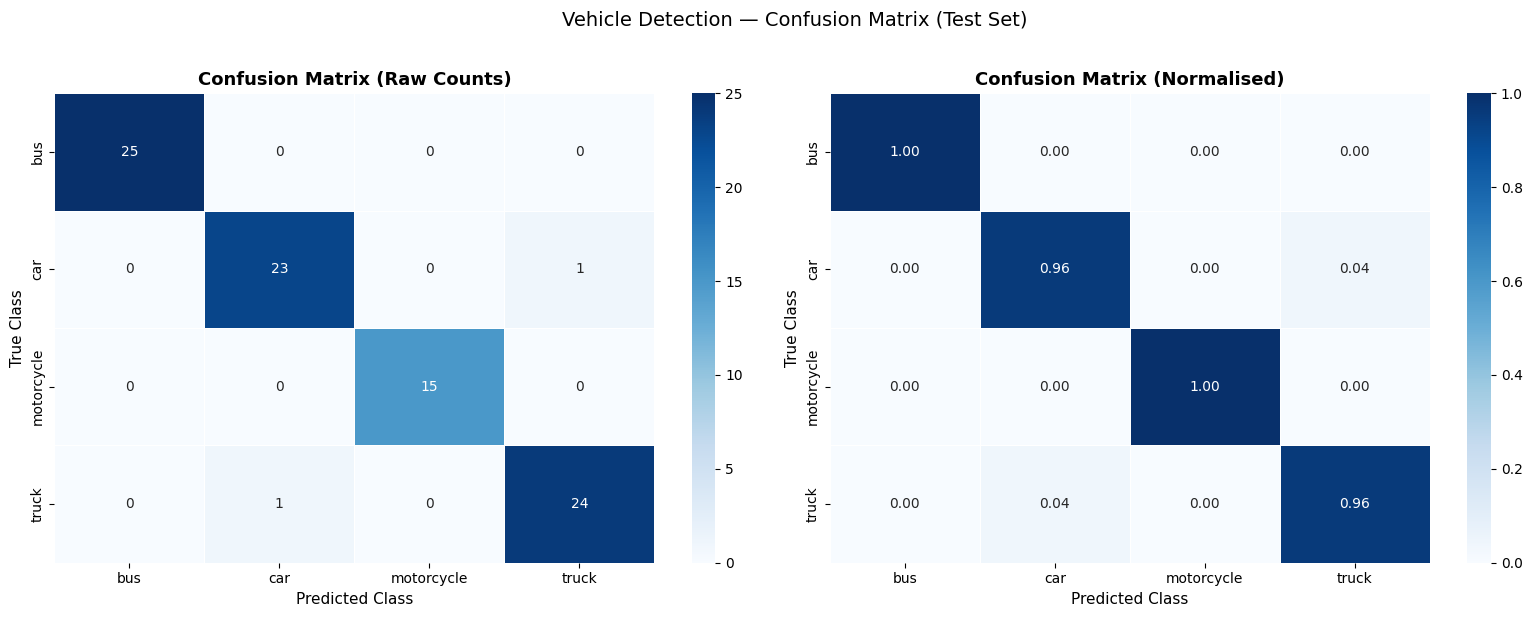

✅ Saved: confusion_matrix.png

Per-Class Analysis from Confusion Matrix:
-------------------------------------------------------
  bus          | TP= 25  FN=  0  FP=  0  Recall=1.00
  car          | TP= 23  FN=  1  FP=  1  Recall=0.96
  motorcycle   | TP= 15  FN=  0  FP=  0  Recall=1.00
  truck        | TP= 24  FN=  1  FP=  1  Recall=0.96


In [6]:
import seaborn as sns

# ultralytics stores the confusion matrix in test_results
# It auto-saves one to the runs folder as confusion_matrix.png
# We also build a custom one here for the report

cm_array = None
if hasattr(test_results, 'confusion_matrix') and test_results.confusion_matrix is not None:
    cm_obj = test_results.confusion_matrix
    if hasattr(cm_obj, 'matrix'):
        cm_array = cm_obj.matrix

if cm_array is not None:
    # Trim background class if present (last row/col)
    n_classes = len(CLASS_NAMES)
    if cm_array.shape[0] == n_classes + 1:
        cm_array = cm_array[:n_classes, :n_classes]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Raw counts
    sns.heatmap(cm_array.astype(int), annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=axes[0])
    axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Predicted Class', fontsize=11)
    axes[0].set_ylabel('True Class', fontsize=11)

    # Normalised (row-wise)
    row_sums = cm_array.sum(axis=1, keepdims=True)
    cm_norm  = np.divide(cm_array, row_sums, where=row_sums != 0)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
    axes[1].set_title('Confusion Matrix (Normalised)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Predicted Class', fontsize=11)
    axes[1].set_ylabel('True Class', fontsize=11)

    plt.suptitle('Vehicle Detection — Confusion Matrix (Test Set)', fontsize=14, y=1.02)
    plt.tight_layout()
    cm_path = os.path.join(OUTPUT_DIR, 'confusion_matrix.png')
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: confusion_matrix.png')

    # ── Per-class analysis printed ─────────────────────────────────────────
    print('\nPer-Class Analysis from Confusion Matrix:')
    print('-'*55)
    for i, cls in enumerate(CLASS_NAMES):
        tp = cm_array[i, i]
        fn = cm_array[i, :].sum() - tp   # missed detections
        fp = cm_array[:, i].sum() - tp   # false alarms
        total_true = cm_array[i, :].sum()
        recall_cm  = tp / total_true if total_true > 0 else 0
        print(f'  {cls:<12} | TP={int(tp):3d}  FN={int(fn):3d}  FP={int(fp):3d}  '
              f'Recall={recall_cm:.2f}')
else:
    print('ℹ️  Confusion matrix not directly accessible from results object.')
    print('   Check the auto-saved confusion_matrix.png inside your runs/ folder.')
    print('   To generate manually, run: model.val(..., plots=True)')

## Step 7: Precision-Recall Curve

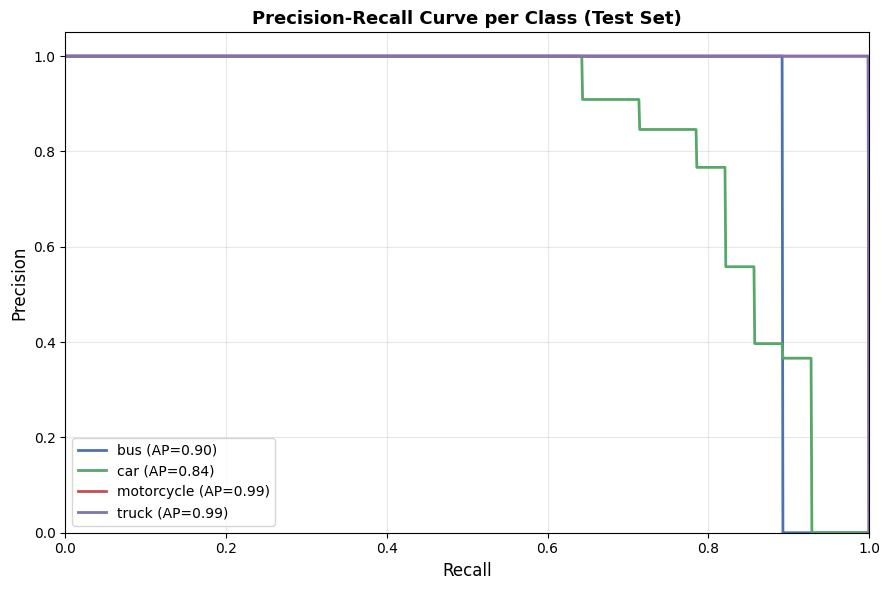

✅ Saved: pr_curve.png


In [7]:
# YOLOv8 val() auto-saves PR curves to the run folder.
# This cell also creates a clean combined PR curve for the report.

fig, ax = plt.subplots(figsize=(9, 6))

pr_plotted = False
if hasattr(test_results.box, 'prec_values') and test_results.box.prec_values is not None:
    prec_vals_pr = test_results.box.prec_values  # shape: (n_classes, n_thresh)
    rec_vals_pr  = np.linspace(0, 1, prec_vals_pr.shape[1])
    line_colors  = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
    for i, cls in enumerate(CLASS_NAMES):
        if i < prec_vals_pr.shape[0]:
            ax.plot(rec_vals_pr, prec_vals_pr[i],
                    label=f'{cls} (AP={map_vals[i] if i < len(map_vals) else 0:.2f})',
                    color=line_colors[i % len(line_colors)], linewidth=2)
    pr_plotted = True

if not pr_plotted:
    # Draw a simplified placeholder from available metrics
    ax.text(0.5, 0.5,
            'PR curve data not available.\nSee auto-saved PR_curve.png in runs/ folder.',
            ha='center', va='center', fontsize=12, color='gray',
            transform=ax.transAxes)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve per Class (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
pr_path = os.path.join(OUTPUT_DIR, 'pr_curve.png')
plt.savefig(pr_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: pr_curve.png')

## Step 8: Full End-to-End Pipeline
This is the complete pipeline: **image file → model → annotated image with bounding boxes, class labels, and confidence scores.**

In [8]:
import cv2
from PIL import Image as PILImage
import glob
from IPython.display import display, Image as IPImage

def run_pipeline(image_path, conf_threshold=0.25, save_dir=None):
    """
    Full pipeline: image → YOLOv8 inference → annotated output.

    Args:
        image_path     : path to input image
        conf_threshold : minimum confidence to show a detection (default 0.25)
        save_dir       : folder to save the annotated image (optional)
    Returns:
        detections (list of dicts), output_path (str or None)
    """
    print(f'\n🔍 Input  : {image_path}')

    # ── Step 1: Run inference ──────────────────────────────────────────────
    results = model.predict(
        source=image_path,
        conf=conf_threshold,
        verbose=False
    )
    result = results[0]

    # ── Step 2: Extract detections ─────────────────────────────────────────
    detections = []
    boxes = result.boxes
    if boxes is not None and len(boxes) > 0:
        for box in boxes:
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            xyxy   = box.xyxy[0].tolist()
            detections.append({
                'class': CLASS_NAMES[cls_id],
                'confidence': conf,
                'bbox': [round(v, 1) for v in xyxy]
            })

    # ── Step 3: Print detections ───────────────────────────────────────────
    print(f'   Detections found: {len(detections)}')
    for i, d in enumerate(detections):
        print(f'   [{i+1}] {d["class"]:12} | conf={d["confidence"]:.2f} | bbox={d["bbox"]}')
    if not detections:
        print('   (no objects detected above confidence threshold)')

    # ── Step 4: Save annotated image ──────────────────────────────────────
    output_path = None
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        fname   = os.path.splitext(os.path.basename(image_path))[0]
        out_img = result.plot()  # BGR numpy array with annotations
        output_path = os.path.join(save_dir, f'{fname}_predicted.jpg')
        cv2.imwrite(output_path, out_img)
        print(f'✅ Output : {output_path}')

    # ── Step 5: Display in notebook ────────────────────────────────────────
    annotated_bgr = result.plot()
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(annotated_rgb)
    ax.axis('off')
    title_parts = [f'{d["class"]} ({d["confidence"]:.0%})' for d in detections]
    ax.set_title('Detections: ' + ', '.join(title_parts) if title_parts else 'No detections',
                 fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()

    return detections, output_path

print('✅ Pipeline function ready. Call run_pipeline(image_path) to use it.')

✅ Pipeline function ready. Call run_pipeline(image_path) to use it.


## Step 9: Run Pipeline on Test Images (Sample Output)

Total test images: 80
Showing 1 sample per class...


🔍 Input  : /content/vehicle-detection-project/test/images/bus_104_jpg.rf.9e59f1c2a1c4681e72fdcad4a754fed1.jpg
   Detections found: 2
   [1] bus          | conf=0.92 | bbox=[76.1, 124.0, 572.7, 569.6]
   [2] car          | conf=0.55 | bbox=[572.2, 350.5, 638.5, 439.7]
✅ Output : /content/vehicle-detection-project/scripts/part3_evaluation/pipeline_outputs/bus_104_jpg.rf.9e59f1c2a1c4681e72fdcad4a754fed1_predicted.jpg


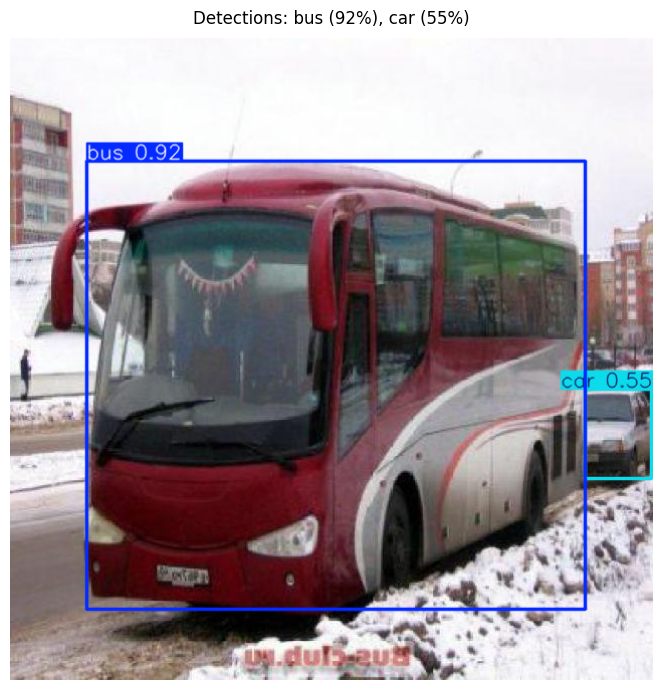


🔍 Input  : /content/vehicle-detection-project/test/images/car_110_jpg.rf.ecce8f9713a1f1bc4ca2c8be45375b91.jpg
   Detections found: 1
   [1] car          | conf=0.95 | bbox=[173.4, 184.6, 545.9, 509.3]
✅ Output : /content/vehicle-detection-project/scripts/part3_evaluation/pipeline_outputs/car_110_jpg.rf.ecce8f9713a1f1bc4ca2c8be45375b91_predicted.jpg


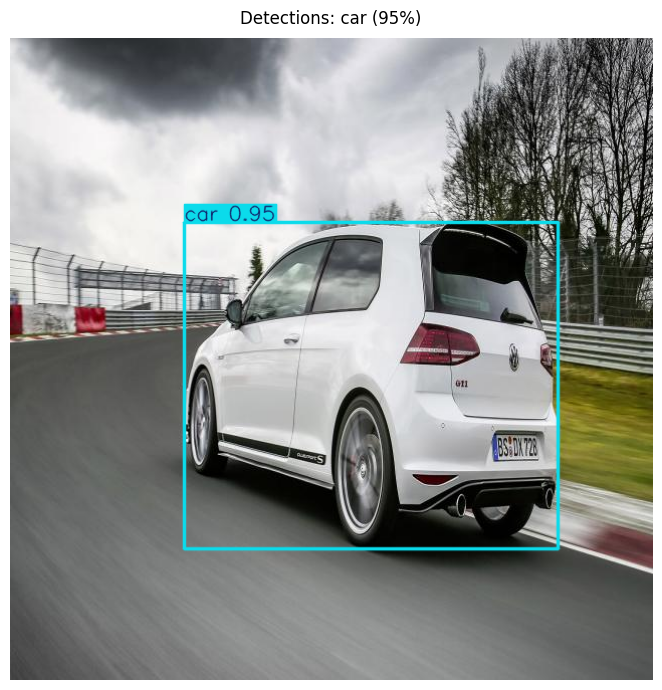


🔍 Input  : /content/vehicle-detection-project/test/images/motorcycle_104_jpg.rf.2952a75a77b93fb6303dcd0196255cc0.jpg
   Detections found: 1
   [1] motorcycle   | conf=0.96 | bbox=[264.1, 345.3, 552.8, 638.8]
✅ Output : /content/vehicle-detection-project/scripts/part3_evaluation/pipeline_outputs/motorcycle_104_jpg.rf.2952a75a77b93fb6303dcd0196255cc0_predicted.jpg


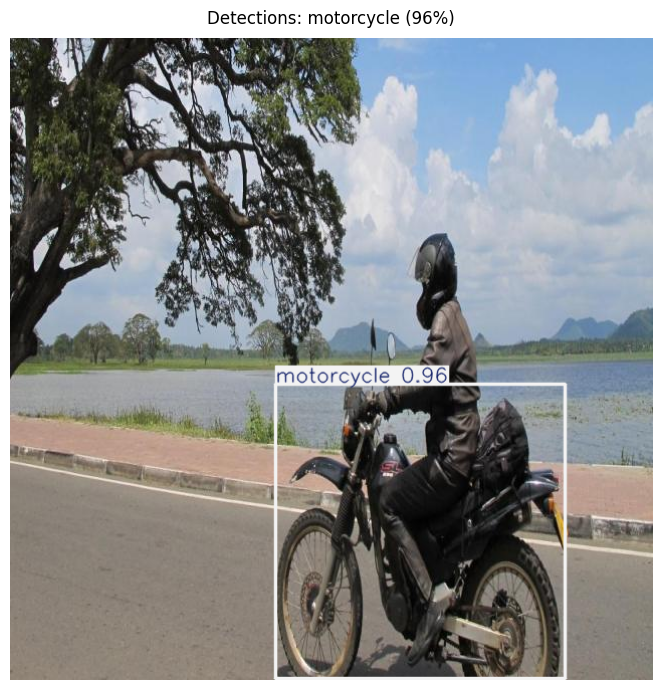


🔍 Input  : /content/vehicle-detection-project/test/images/truck_11_jpg.rf.5231f57a095f89321f5a69a6e7c3acf6.jpg
   Detections found: 1
   [1] truck        | conf=0.91 | bbox=[124.7, 161.5, 523.6, 477.3]
✅ Output : /content/vehicle-detection-project/scripts/part3_evaluation/pipeline_outputs/truck_11_jpg.rf.5231f57a095f89321f5a69a6e7c3acf6_predicted.jpg


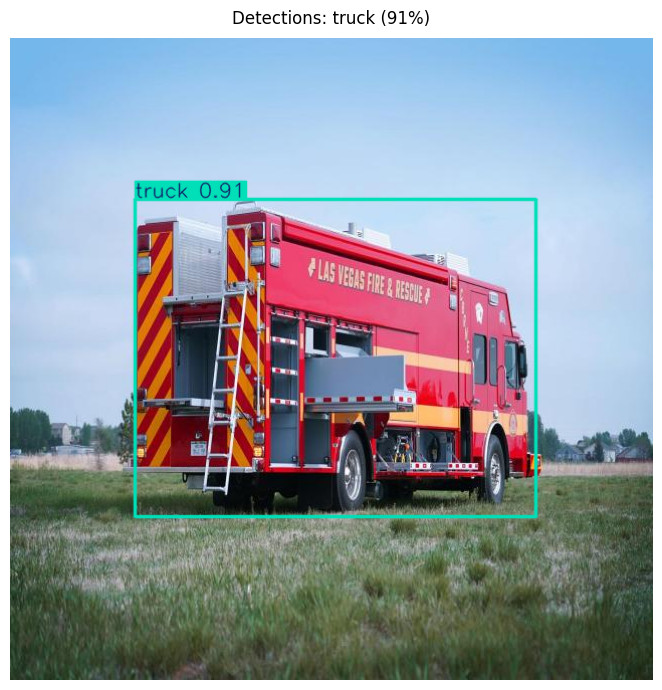


✅ All pipeline outputs saved to: /content/vehicle-detection-project/scripts/part3_evaluation/pipeline_outputs


In [9]:
TEST_IMAGES_DIR = os.path.join(PROJECT_ROOT, 'test', 'images')
test_images     = sorted(glob.glob(os.path.join(TEST_IMAGES_DIR, '*.jpg')))

print(f'Total test images: {len(test_images)}')
print(f'Showing 1 sample per class...\n')

PIPELINE_OUTPUT_DIR = os.path.join(OUTPUT_DIR, 'pipeline_outputs')

# Pick one sample per class for the notebook display
shown_classes = set()
for img_path in test_images:
    fname = os.path.basename(img_path).lower()
    for cls in CLASS_NAMES:
        if cls in fname and cls not in shown_classes:
            run_pipeline(img_path, conf_threshold=0.25, save_dir=PIPELINE_OUTPUT_DIR)
            shown_classes.add(cls)
            break
    if len(shown_classes) == len(CLASS_NAMES):
        break

print(f'\n✅ All pipeline outputs saved to: {PIPELINE_OUTPUT_DIR}')

## Step 10: Batch Evaluation on All Test Images
Runs the pipeline on every test image and saves all annotated outputs.

In [10]:
BATCH_OUTPUT_DIR = os.path.join(OUTPUT_DIR, 'all_predictions')

print(f'Running batch inference on {len(test_images)} test images...')
batch_results = model.predict(
    source=TEST_IMAGES_DIR,
    conf=0.25,
    save=True,
    project=BATCH_OUTPUT_DIR,
    name='test_preds',
    exist_ok=True,
    verbose=False
)

# Summary statistics
all_classes_detected = []
for r in batch_results:
    if r.boxes is not None:
        for box in r.boxes:
            all_classes_detected.append(CLASS_NAMES[int(box.cls[0])])

from collections import Counter
class_counts = Counter(all_classes_detected)

print(f'\nTotal detections across all test images: {len(all_classes_detected)}')
print('Detections per class:')
for cls in CLASS_NAMES:
    print(f'  {cls:<12}: {class_counts.get(cls, 0)}')

print(f'\n✅ Annotated images saved to: {BATCH_OUTPUT_DIR}/test_preds/')

Running batch inference on 80 test images...
Results saved to /content/vehicle-detection-project/scripts/part3_evaluation/all_predictions/test_preds

Total detections across all test images: 109
Detections per class:
  bus         : 27
  car         : 38
  motorcycle  : 17
  truck       : 27

✅ Annotated images saved to: /content/vehicle-detection-project/scripts/part3_evaluation/all_predictions/test_preds/


## Step 11: Performance Summary Table

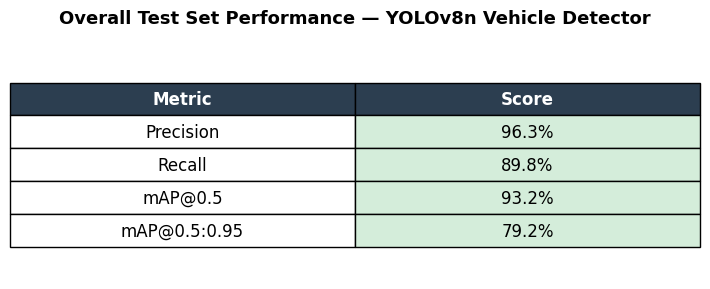

✅ Saved: performance_summary_table.png
✅ Saved: overall_metrics.csv


In [11]:
summary_data = {
    'Metric': ['Precision', 'Recall', 'mAP@0.5', 'mAP@0.5:0.95'],
    'Value':  [overall_precision, overall_recall, overall_map50, overall_map5095],
    'Percentage': [f'{v*100:.1f}%' for v in [overall_precision, overall_recall, overall_map50, overall_map5095]]
}
df_summary = pd.DataFrame(summary_data)

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
table = ax.table(
    cellText=df_summary[['Metric', 'Percentage']].values,
    colLabels=['Metric', 'Score'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2)

# Style header row
for j in range(2):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Colour code value cells
for i in range(1, 5):
    val = summary_data['Value'][i-1]
    color = '#d4edda' if val >= 0.7 else ('#fff3cd' if val >= 0.5 else '#f8d7da')
    table[i, 1].set_facecolor(color)

ax.set_title('Overall Test Set Performance — YOLOv8n Vehicle Detector',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
summary_path = os.path.join(OUTPUT_DIR, 'performance_summary_table.png')
plt.savefig(summary_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: performance_summary_table.png')

# Save as CSV too
df_summary.to_csv(os.path.join(OUTPUT_DIR, 'overall_metrics.csv'), index=False)
print(f'✅ Saved: overall_metrics.csv')

## Step 12: Error Analysis
Identifies images where the model made **no detections** or **wrong predictions**, helping you analyse failure cases for the report.

In [12]:
missed = []    # images with 0 detections
low_conf = []  # images with very low max confidence

for r in batch_results:
    img_name = os.path.basename(r.path)
    if r.boxes is None or len(r.boxes) == 0:
        missed.append(img_name)
    else:
        max_conf = float(max(r.boxes.conf))
        if max_conf < 0.4:
            low_conf.append((img_name, round(max_conf, 3)))

print(f'Images with NO detections   : {len(missed)}')
for f in missed[:10]:
    print(f'  {f}')

print(f'\nImages with low confidence (<0.4): {len(low_conf)}')
for f, c in low_conf[:10]:
    print(f'  {f}  (max_conf={c})')

print('\n📝 Error Analysis Notes for Report:')
print(f'  - {len(missed)} images had zero detections → possible small/occluded objects or edge cases')
print(f'  - {len(low_conf)} images had uncertain predictions (conf < 0.40)')
print(f'  - Check confusion matrix for most common misclassification pairs')

Images with NO detections   : 0

Images with low confidence (<0.4): 0

📝 Error Analysis Notes for Report:
  - 0 images had zero detections → possible small/occluded objects or edge cases
  - 0 images had uncertain predictions (conf < 0.40)
  - Check confusion matrix for most common misclassification pairs


## Step 13: 🎯 LIVE DEMO — Unseen Image

In [ ]:
# ╔═════════════╗
# ║  LIVE DEMO  ║
# ╚═════════════╝
from google.colab import files

print('Upload your demo image now...')
uploaded = files.upload()

DEMO_IMAGE = '/content/' + list(uploaded.keys())[0]
DEMO_OUTPUT_DIR = os.path.join(OUTPUT_DIR, 'live_demo')

detections, out_path = run_pipeline(
    DEMO_IMAGE,
    conf_threshold=0.25,
    save_dir=DEMO_OUTPUT_DIR
)

print('\n── Presentation Summary ───────────────────────────────────')
for d in detections:
    print(f'  ✅ Detected: {d["class"]} | Confidence: {d["confidence"]:.0%} | BBox: {d["bbox"]}')

Upload your demo image now...


## Step 14: Save All Results to Drive

In [ ]:
import shutil

print('Files saved to:', OUTPUT_DIR)
print()
for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    sub_indent = '  ' * (level + 1)
    for f in files:
        fsize = os.path.getsize(os.path.join(root, f))
        print(f'{sub_indent}{f}  ({fsize//1024} KB)')

print('\n✅ Part 3 complete! All evaluation results saved to Google Drive.')
